# Forecast with known-future exogenous variables

Use **`df`** for history (`unique_id`, `ds`, `y`, and exog columns in the past) and **`X_df`** for
known-future exog over the next `h` steps (no `y`). See [Exogenous variables](../exogenous-variables.md)
for the full API.

**Dataset:** panel built from fev-bench `epf_*` markets (BE, DE, FR, NP, PJM) with two covariates
per market, unified as `ex_1` and `ex_2`.

**Models:** `Tafsut` uses `exog_strategy="auto"` (linear `XReg` fallback) and **Chronos-2** uses native
exog. Both support **`level`** with exog.

## Import libraries

In [2]:
import pandas as pd

from foundationforecast import FoundationForecast

/Users/azul/projects/foundationforecast/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:datasets:JAX version 0.7.1 available.


## Load the dataset

- **`train.parquet`:** history with `y`, `ex_1`, and `ex_2`
- **`test.parquet`:** 24-hour horizon with exog (and `y` for evaluation)

For cross-validation we concatenate train and test so the last `h` steps match the fev-bench holdout.
`X_df` carries horizon exog only.

In [3]:
df = pd.read_parquet("https://timecopilot.s3.amazonaws.com/public/data/electricity_price/train.parquet") 
X_df = pd.read_parquet("https://timecopilot.s3.amazonaws.com/public/data/electricity_price/test.parquet")
y_test_df = X_df[["unique_id", "ds", "y"]]
X_df = X_df.drop(columns=["y"])

df.head()

,unique_id,ds,y,ex_1,ex_2
0,BE,2011-01-09 00:00:00,32.540001,63065.0,63000.0
1,BE,2011-01-09 01:00:00,21.549999,62715.0,58800.0
2,BE,2011-01-09 02:00:00,15.710000,61952.0,58500.0
3,BE,2011-01-09 03:00:00,10.580000,59262.0,54300.0
4,BE,2011-01-09 04:00:00,10.320000,56883.0,51900.0


In [4]:
X_df.head()

,unique_id,ds,ex_1,ex_2
0,BE,2016-12-12 00:00:00,56275.0,64188.0
1,BE,2016-12-12 01:00:00,54866.0,61076.0
2,BE,2016-12-12 02:00:00,56534.0,61246.0
3,BE,2016-12-12 03:00:00,56042.0,58082.0
4,BE,2016-12-12 04:00:00,56114.0,56397.0


In [5]:
y_test_df.head()

,unique_id,ds,y
0,BE,2016-12-12 00:00:00,35.099998
1,BE,2016-12-12 01:00:00,30.440001
2,BE,2016-12-12 02:00:00,35.099998
3,BE,2016-12-12 03:00:00,35.099998
4,BE,2016-12-12 04:00:00,33.020000


## Plot the data

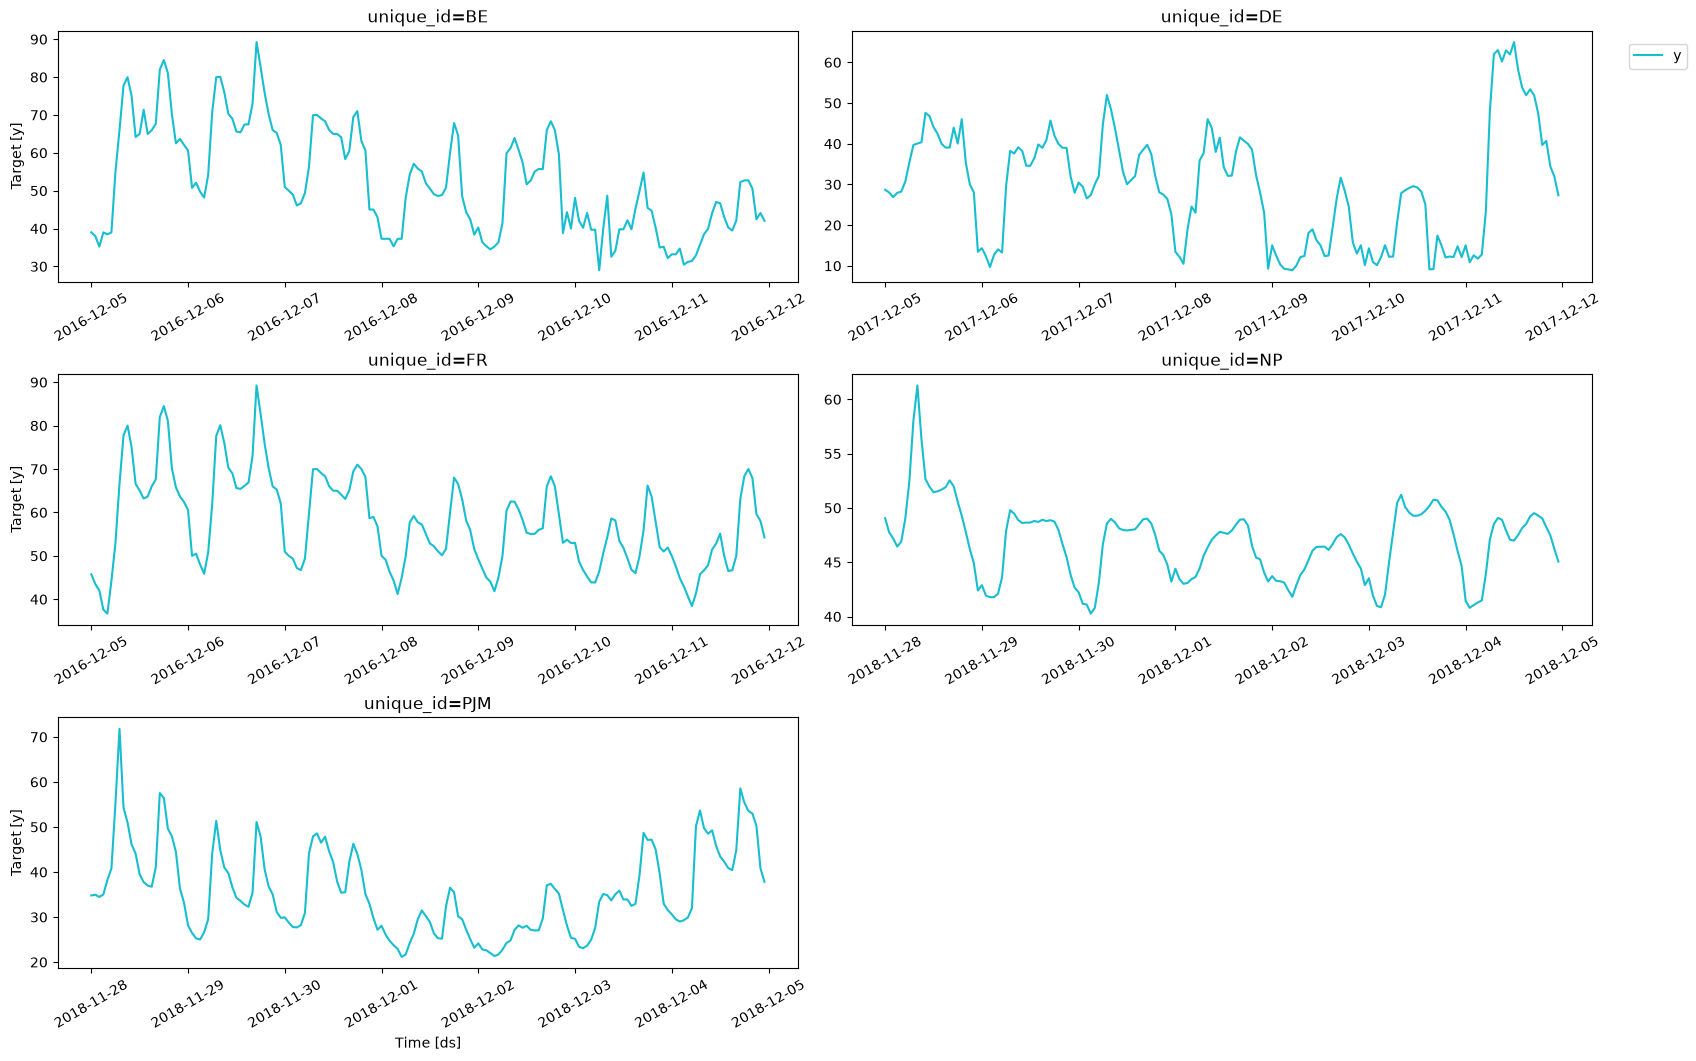

In [6]:
FoundationForecast.plot(df, max_insample_length=24 * 7)

## Import the models

In [13]:
from foundationforecast.models import Chronos, T0, Tafsut, TimesFM, TiRex
from foundationforecast.core import XReg

## Create a FoundationForecast

In [15]:
models = [
    Tafsut(alias="Tafsut", exog_strategy=XReg(fm_first=False)), # default is "auto"
    TimesFM(repo_id="google/timesfm-3.0-pytorch", alias="TimesFM-3"),
    T0(repo_id="theforecastingcompany/t0-beta", alias="t0-beta"),
    #TiRex(repo_id="NX-AI/TiRex-2", alias="TiRex-2"),
    Chronos(repo_id="amazon/chronos-2", alias="Chronos-2"),
]

ff = FoundationForecast(models=models)

In [16]:
fcst_df = ff.forecast(df, h=24, X_df=X_df, level=[80, 90])

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 2726.16it/s]


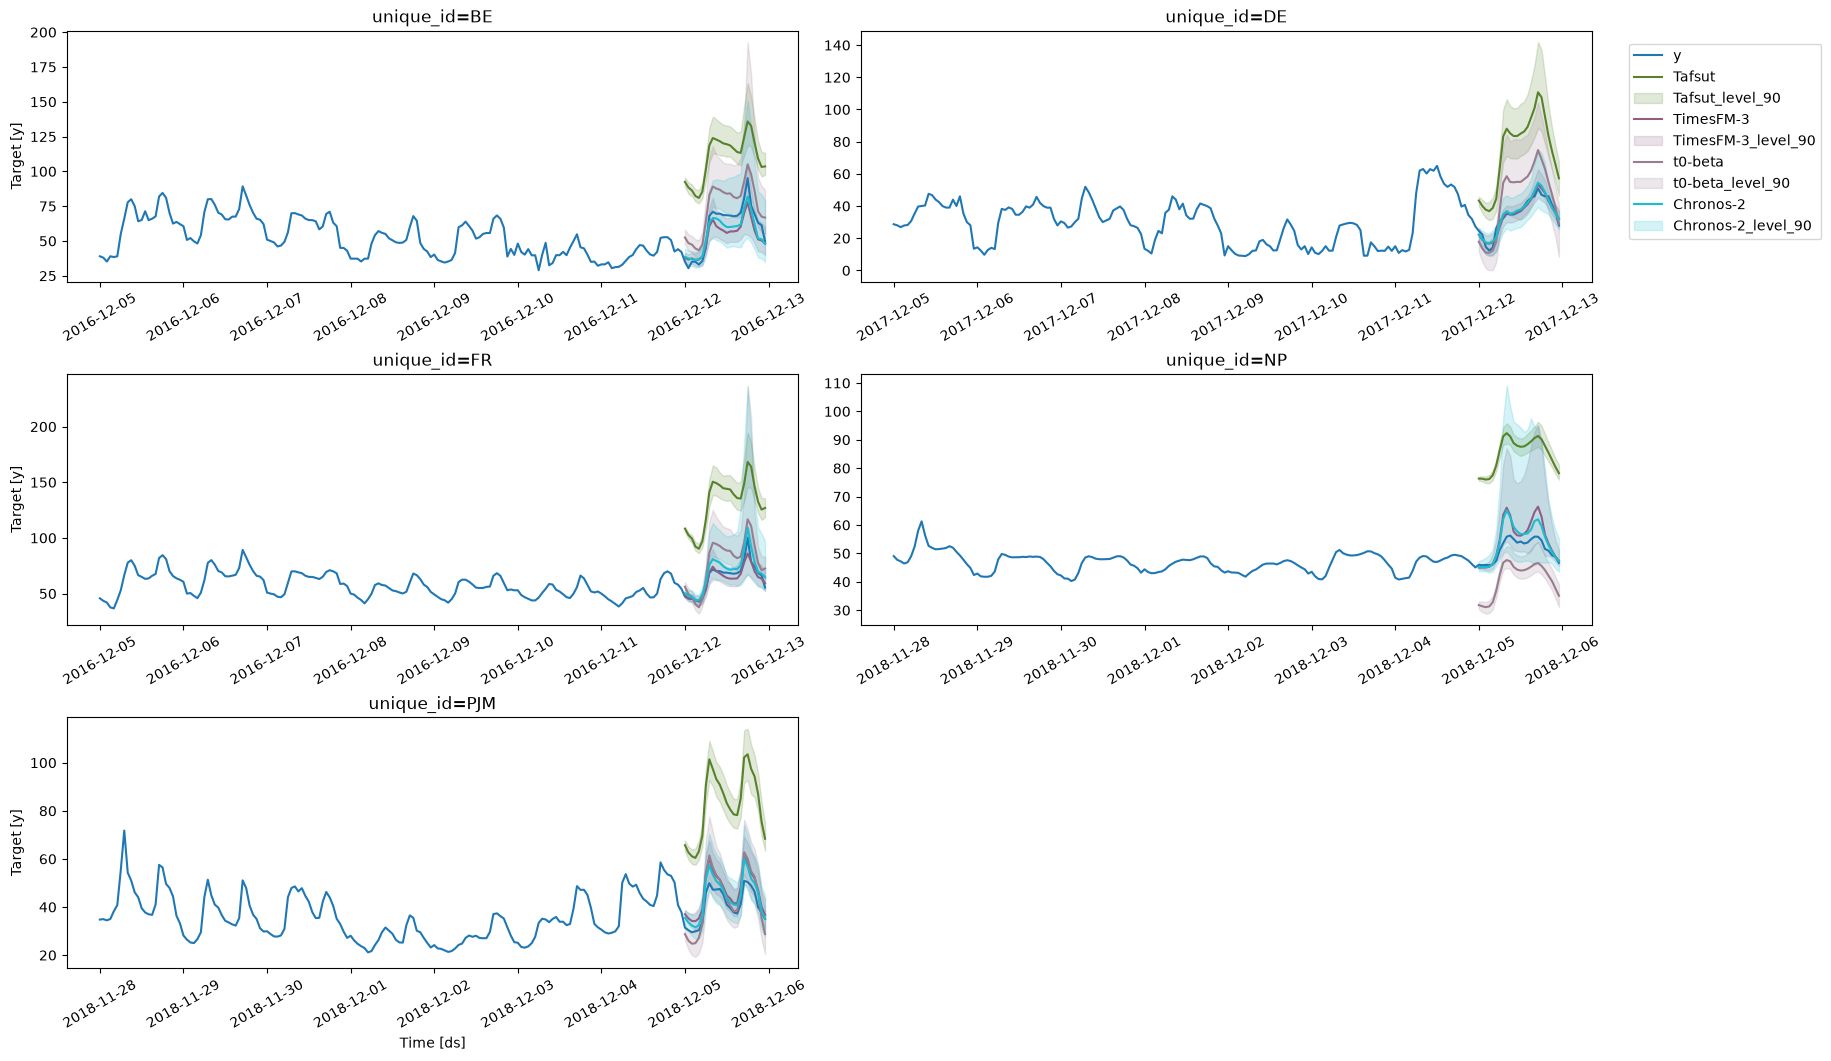

In [17]:
ff.plot(df, fcst_df.merge(y_test_df, on=["unique_id", "ds"]), max_insample_length=24 * 7, level=[90])

In [25]:
level = [80, 90]
h = 24

cv_df = ff.cross_validation(
    df=df,
    h=h,
    freq="h",
    level=level,
    n_windows=1,
)

0it [00:00, ?it/s]

100%|██████████| 1/1 [00:01<00:00,  1.85s/it]
1it [00:03,  3.38s/it]
Loading weights: 100%|██████████| 170/170 [00:00<00:00, 23094.89it/s]
1it [00:03,  3.85s/it]


In [ ]:
ff.plot(
    df.query("unique_id == 'DE'"),
    cv_df.query("unique_id == 'DE'").drop(columns=["cutoff", "y"]),
    level=[80],
)

In [ ]:
cv_df.head()

## Evaluation

In [26]:
from functools import partial

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, scaled_crps

In [28]:
eval_df = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=df,
    metrics=[partial(mase, seasonality=24), scaled_crps],
    level=level,
)
eval_df.groupby("metric").mean(numeric_only=True).T.round(3)

metric,mase,scaled_crps
Tafsut,6.429,0.668
Chronos-2,0.691,0.031
